In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine
import pandas as pd

from inference import ( InferenceEngine, predict_with_confidence, visualize_prediction_tiff, 
                        save_prediction_tiff, _load_barangay_band_from_geojson, compute_class_pcts )

# ── Visual constants ──────────────────────────────────────────────────────────
FLOOD_COLORS = {0: '#FFFFFF', 1: '#C6DBEF', 2: '#6BAED6', 3: '#2171B5', 4: '#08306B'}
FLOOD_LABELS = {0:'No Flood', 1:'Light', 2:'Moderate', 3:'Heavy', 4:'Extreme'}

# Mask -1 values so they render as fully transparent
flood_cmap = mcolors.ListedColormap([FLOOD_COLORS[i] for i in range(5)])
flood_cmap.set_bad(alpha=0)                          # -1 → transparent
legend_patches = [mpatches.Patch(color=FLOOD_COLORS[i], label=FLOOD_LABELS[i]) for i in range(5)]
flood_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 6)

# ── GeoTIFF save helper ───────────────────────────────────────────────────────
src_left, src_top   = 13457490.0, 1664610.0
src_W,    src_H     = 1125,       1224          # original size
dst_W,    dst_H     = 1152,       1152          # resampled size
src_right           = 13491240.0
src_bottom          = 1627890.0

new_pixel_x = (src_right  - src_left) / dst_W   # 33750 / 1152 = 29.296875
new_pixel_y = (src_bottom - src_top)  / dst_H   # -36720 / 1152 = -31.875

dem_transform = Affine(new_pixel_x, 0.0, src_left, 0.0, new_pixel_y, src_top)
dem_crs       = rasterio.crs.CRS.from_epsg(3857)

_GEOJSON_PATH  = 'manila_barangay_geojson.geojson'
_H, _W         = 1152, 1152

_barangay_band = _load_barangay_band_from_geojson(_GEOJSON_PATH, dem_transform, dem_crs, _H, _W)
print(f"  Barangay band ready  : {_barangay_band.shape}"
      f"  | {len(np.unique(_barangay_band[_barangay_band > 0]))} barangays"
      f"  | coverage {100*(_barangay_band > 0).mean():.1f}%")


  Rasterizing 1011 barangays within DEM extent ...
  Barangay band ready  : (1152, 1152)  | 1009 barangays  | coverage 5.4%


[InferenceEngine] device = cpu
[InferenceEngine] Loaded 6,075 Manila patches  | spatial (6075, 3, 4, 4)  | dem (1152, 1152)
[InferenceEngine] Auto-selected: fold_1_best.pth  (macro_f1=0.4610)
[InferenceEngine] Model loaded  ← fold_1_best.pth

  Predicting: Front-Loaded, 20 mm
  Conditioning: pattern_type=0  depth_norm=0.205  tpeak=0.00  has_tpeak=0

  Flooded area : 5.5%  (332 / 6,075 patches)
  Mean confidence : 0.671

  Class           Count       %   Avg conf
  ------------------------------------------
  No Flood        5,743   94.5%      0.685
  Light               6    0.1%      0.355
  Moderate           66    1.1%      0.381
  Heavy             149    2.5%      0.378
  Extreme           111    1.8%      0.521
✓ Saved → outputs\predictions\front_loaded_20mm.tif
  ✓ front_loaded_20mm

  Predicting: Front-Loaded, 35 mm
  Conditioning: pattern_type=0  depth_norm=0.411  tpeak=0.00  has_tpeak=0

  Flooded area : 31.5%  (1,916 / 6,075 patches)
  Mean confidence : 0.638

  Class       

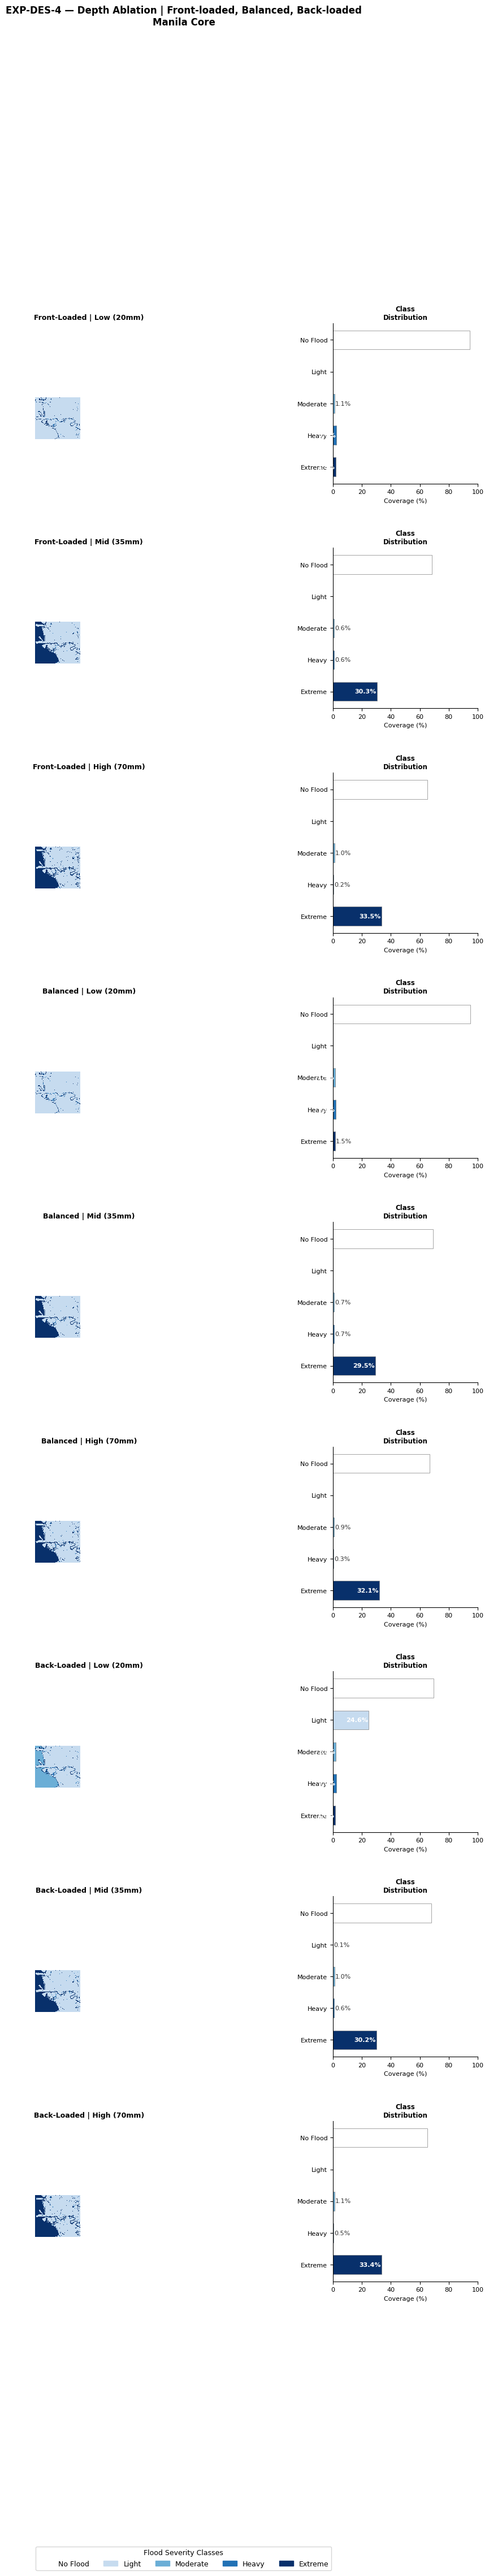

✓ Figure 1 saved


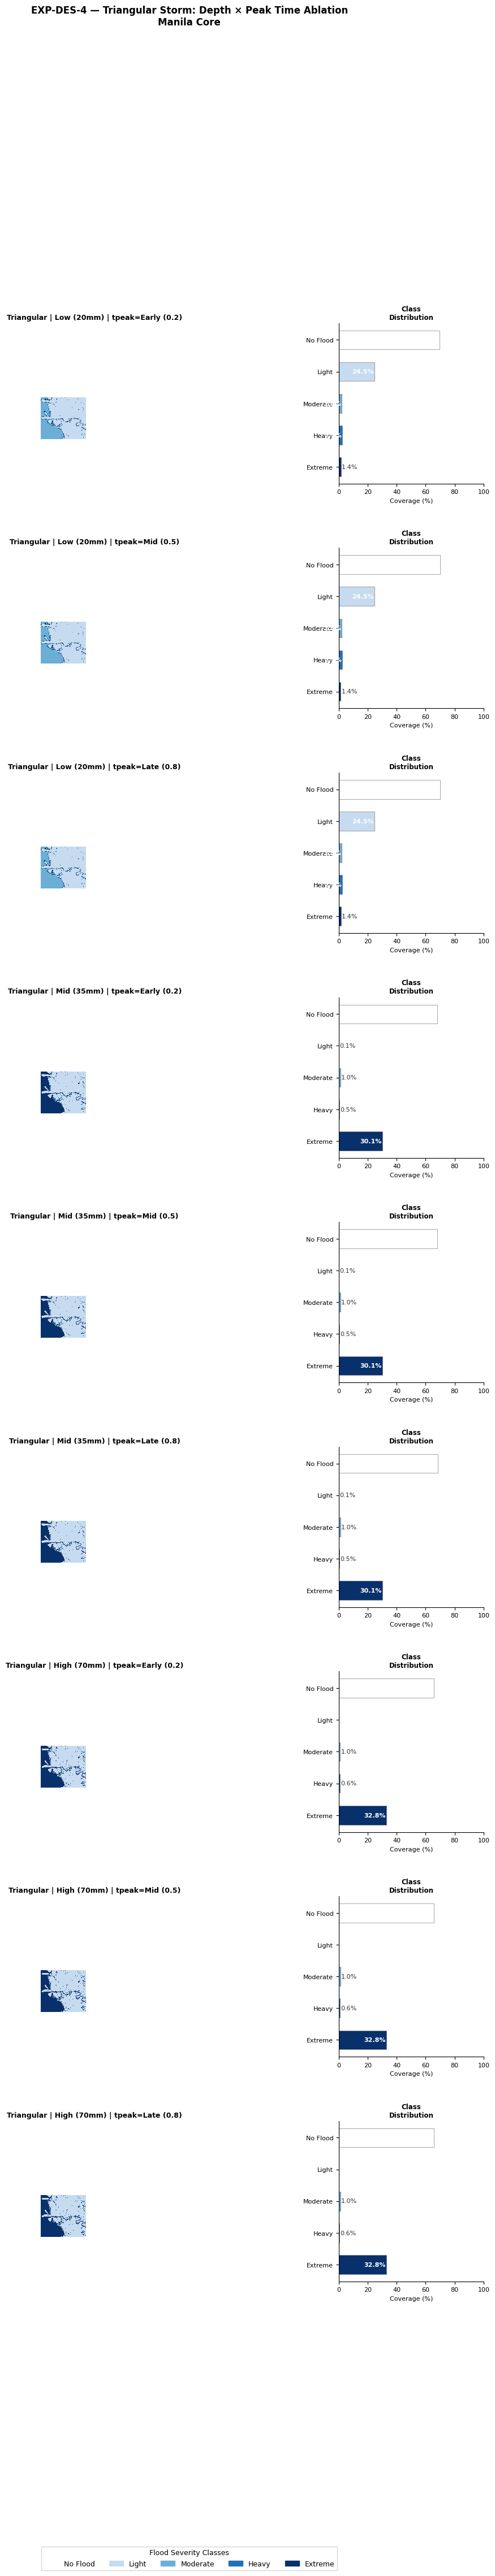

✓ Figure 2 saved

DEPTH / TPEAK ABLATION SUMMARY

  Front-Loaded
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ------------------------------------------------------------------------------
  Low (20mm)         0.6708       30.7%     94.5%    0.1%   1.1%    2.5%      1.8%
  Mid (35mm)         0.6377       29.3%     68.5%    0.0%   0.6%    0.6%     30.3%
  High (70mm)        0.5669       47.6%     65.3%    0.0%   1.0%    0.2%     33.5%

  Balanced
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%
  ------------------------------------------------------------------------------
  Low (20mm)         0.6732       30.7%     94.9%    0.1%   1.5%    1.9%      1.5%
  Mid (35mm)         0.6494       29.1%     69.1%    0.1%   0.7%    0.7%     29.5%
  High (70mm)        0.5903       32.7%     66.7%    0.0%   0.9%    0.3%     32.1%

  Back-Loaded
  Depth             AvgConf  Uncertain%  NoFlood%  Light%   Mod%  Heavy%  Extreme%

In [2]:
engine = InferenceEngine(patch_data_path = 'outputs/spatial_data.npz')

# ══════════════════════════════════════════════════════════════════════════════
# DEPTH & TPEAK ABLATION — ALL 4 STORM TYPES
#
# Depth levels chosen to span the training range (6mm–78mm):
#   Low  : ~20mm  (light rainfall, near training minimum)
#   Mid  : ~35mm  (moderate, well-represented in all storm types)
#   High : ~70mm  (heavy, near training maximum)
#
# Triangular also varies tpeak: 0.2 (early), 0.5 (mid), 0.8 (late)
# giving a 3×3 grid of depth × tpeak for that storm type.
# ══════════════════════════════════════════════════════════════════════════════

DEPTHS  = [20, 35, 70]
TPEAKS  = [0.2, 0.5, 0.8]

DEPTH_LABELS = {20: 'Low (20mm)', 35: 'Mid (35mm)', 70: 'High (70mm)'}
TPEAK_LABELS = {0.2: 'Early (0.2)', 0.5: 'Mid (0.5)', 0.8: 'Late (0.8)'}

output_dir = Path('outputs/predictions')
output_dir.mkdir(parents=True, exist_ok=True)

# ── Storage ───────────────────────────────────────────────────────────────────
results_depth = {st: {} for st in ['front-loaded', 'balanced', 'back-loaded']}
results_tri   = {d:  {} for d  in DEPTHS}

# ── Run predictions ───────────────────────────────────────────────────────────
# Non-triangular: depth ablation only
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        result = predict_with_confidence(engine, storm_type=storm_type, depth_mm=depth)
        results_depth[storm_type][depth] = result
        slug = f"{storm_type.replace('-','_')}_{depth}mm"
        save_prediction_tiff(result, engine, dem_crs, dem_transform, _barangay_band, str(output_dir / f'{slug}.tif'))
        print(f'  ✓ {slug}')

# Triangular: depth × tpeak grid
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result = predict_with_confidence(engine, storm_type='triangular', depth_mm=depth, tpeak=tpeak)
        results_tri[depth][tpeak] = result
        slug = f"triangular_{depth}mm_tpeak{str(tpeak).replace('.','')}"
        save_prediction_tiff(result, engine, dem_crs, dem_transform, _barangay_band, str(output_dir / f'{slug}.tif'))
        print(f'  ✓ {slug}')

print(f'\n✓ All predictions saved → {output_dir}')

# ── Figure 1: Depth ablation — front-loaded, balanced, back-loaded ────────────
fig1, axes1 = plt.subplots(9, 2, figsize=(13, 45), gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.25})
row = 0
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        result   = results_depth[storm_type][depth]
        ax_flood = axes1[row, 0]
        ax_bar   = axes1[row, 1]
        pcts     = compute_class_pcts(result['flood_map'])

        ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                        interpolation='nearest')
        ax_flood.set_title(f'{storm_type.title()} | {DEPTH_LABELS[depth]}',
            fontsize=9, fontweight='bold', pad=5)
        ax_flood.axis('off')

        bar_labels = [FLOOD_LABELS[i] for i in range(5)]
        values     = [pcts[i] for i in range(5)]
        colors     = [FLOOD_COLORS[i] for i in range(5)]
        bars       = ax_bar.barh(bar_labels, values, color=colors,
                                 edgecolor='gray', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            if val > 1.5:
                ax_bar.text(bar.get_width() - 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='right',
                            fontsize=8, color='white', fontweight='bold')
            elif val > 0.1:
                ax_bar.text(bar.get_width() + 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='left',
                            fontsize=8, color='#333333')
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel('Coverage (%)', fontsize=8)
        ax_bar.set_title('Class\nDistribution', fontsize=8.5,
                         fontweight='bold', pad=5)
        ax_bar.tick_params(axis='both', labelsize=8)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.invert_yaxis()
        row += 1

fig1.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
            frameon=True, title='Flood Severity Classes', title_fontsize=9,
            bbox_to_anchor=(0.5, -0.005))
fig1.suptitle(
    'EXP-DES-4 — Depth Ablation | Front-loaded, Balanced, Back-loaded\nManila Core',
    fontsize=12, fontweight='bold', y=1.005)
plt.savefig(str(output_dir / 'ablation_depth_non_triangular.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure 1 saved')


# ── Figure 2: Triangular depth × tpeak grid ───────────────────────────────────
# Layout: 9 combos (3 depths × 3 tpeaks) rows, 2 cols (flood map | bar)
fig2, axes2 = plt.subplots(
    9, 2, figsize=(13, 45),
    gridspec_kw={'width_ratios': [2.5, 1], 'hspace': 0.40, 'wspace': 0.25}
)
row = 0
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result   = results_tri[depth][tpeak]
        ax_flood = axes2[row, 0]
        ax_bar   = axes2[row, 1]
        pcts     = compute_class_pcts(result['flood_map'])

        ax_flood.imshow(result['flood_map'], cmap=flood_cmap, norm=flood_norm,
                        interpolation='nearest')
        ax_flood.set_title(
            f'Triangular | {DEPTH_LABELS[depth]} | tpeak={TPEAK_LABELS[tpeak]}',
            fontsize=9, fontweight='bold', pad=5)
        ax_flood.axis('off')

        bar_labels = [FLOOD_LABELS[i] for i in range(5)]
        values     = [pcts[i] for i in range(5)]
        colors     = [FLOOD_COLORS[i] for i in range(5)]
        bars       = ax_bar.barh(bar_labels, values, color=colors,
                                 edgecolor='gray', linewidth=0.5, height=0.6)
        for bar, val in zip(bars, values):
            if val > 1.5:
                ax_bar.text(bar.get_width() - 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='right',
                            fontsize=8, color='white', fontweight='bold')
            elif val > 0.1:
                ax_bar.text(bar.get_width() + 0.5,
                            bar.get_y() + bar.get_height() / 2,
                            f'{val:.1f}%', va='center', ha='left',
                            fontsize=8, color='#333333')
        ax_bar.set_xlim(0, 100)
        ax_bar.set_xlabel('Coverage (%)', fontsize=8)
        ax_bar.set_title('Class\nDistribution', fontsize=8.5,
                         fontweight='bold', pad=5)
        ax_bar.tick_params(axis='both', labelsize=8)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.invert_yaxis()
        row += 1

fig2.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
            frameon=True, title='Flood Severity Classes', title_fontsize=9,
            bbox_to_anchor=(0.5, -0.005))
fig2.suptitle(
    'EXP-DES-4 — Triangular Storm: Depth × Peak Time Ablation\nManila Core',
    fontsize=12, fontweight='bold', y=1.005)
plt.savefig(str(output_dir / 'ablation_triangular_depth_tpeak.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure 2 saved')


# ── Summary table ─────────────────────────────────────────────────────────────
print('\n' + '='*75)
print('DEPTH / TPEAK ABLATION SUMMARY')
print('='*75)

# Non-triangular
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    print(f'\n  {storm_type.title()}')
    print(f'  {"Depth":<16} {"AvgConf":>8} {"Uncertain%":>11} '
          f'{"NoFlood%":>9} {"Light%":>7} {"Mod%":>6} {"Heavy%":>7} {"Extreme%":>9}')
    print(f'  {"-"*78}')
    for depth in DEPTHS:
        result      = results_depth[storm_type][depth]
        patch_confs = result['confidence']
        pcts        = compute_class_pcts(result['flood_map'])
        print(f'  {DEPTH_LABELS[depth]:<16} '
              f'{patch_confs.mean():>8.4f} '
              f'{100*(patch_confs<0.5).mean():>10.1f}% '
              f'{pcts[0]:>8.1f}% '
              f'{pcts[1]:>6.1f}% '
              f'{pcts[2]:>5.1f}% '
              f'{pcts[3]:>6.1f}% '
              f'{pcts[4]:>8.1f}%')

# Triangular
print(f'\n  Triangular')
print(f'  {"Depth × tpeak":<22} {"AvgConf":>8} {"Uncertain%":>11} '
      f'{"NoFlood%":>9} {"Light%":>7} {"Mod%":>6} {"Heavy%":>7} {"Extreme%":>9}')
print(f'  {"-"*84}')
for depth in DEPTHS:
    for tpeak in TPEAKS:
        result      = results_tri[depth][tpeak]
        patch_confs = result['confidence']
        pcts        = compute_class_pcts(result['flood_map'])
        label       = f'{DEPTH_LABELS[depth]} | tp={tpeak}'
        print(f'  {label:<22} '
              f'{patch_confs.mean():>8.4f} '
              f'{100*(patch_confs<0.5).mean():>10.1f}% '
              f'{pcts[0]:>8.1f}% '
              f'{pcts[1]:>6.1f}% '
              f'{pcts[2]:>5.1f}% '
              f'{pcts[3]:>6.1f}% '
              f'{pcts[4]:>8.1f}%')

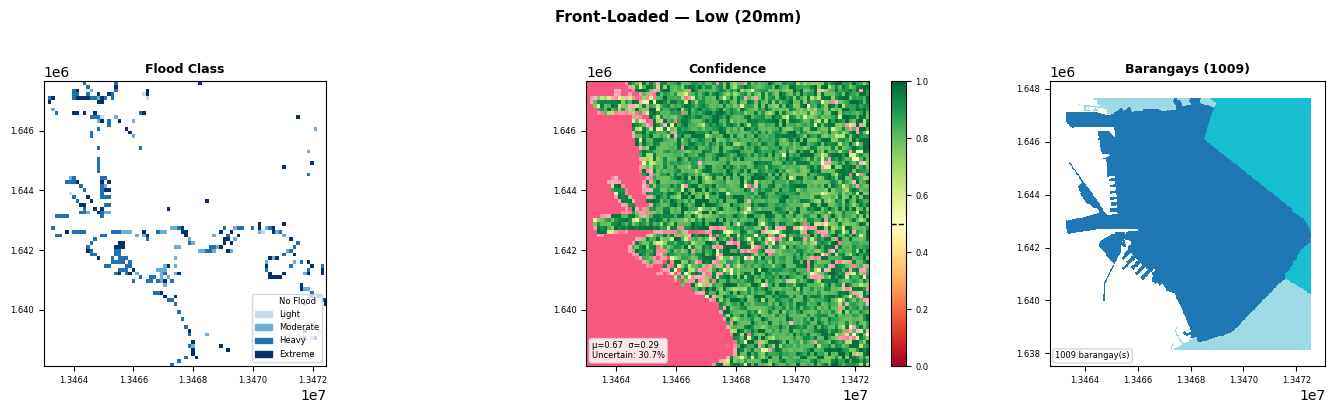

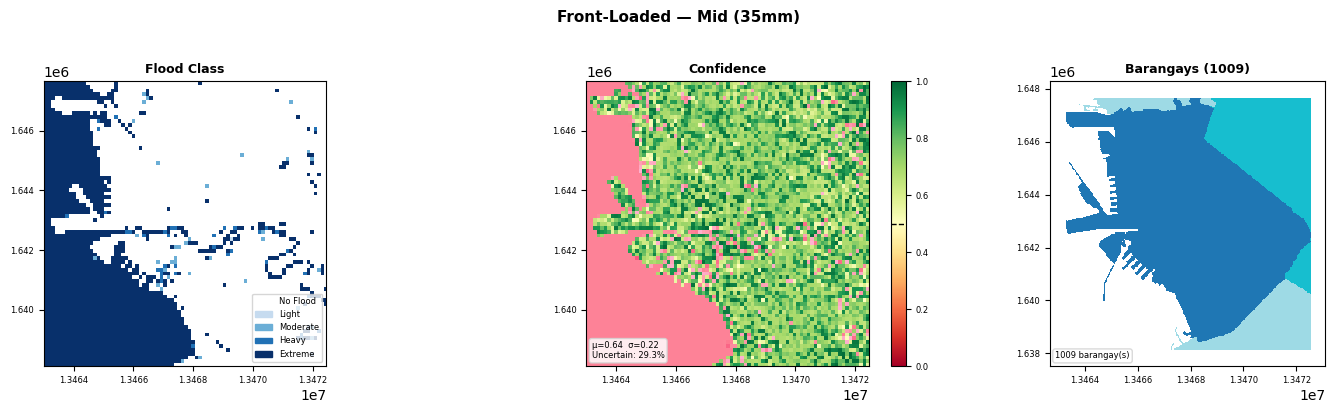

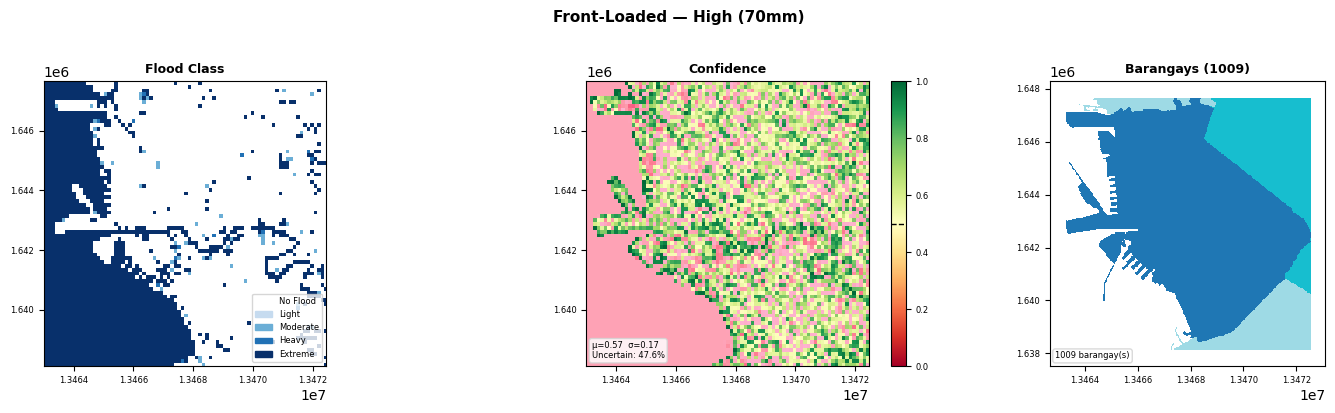

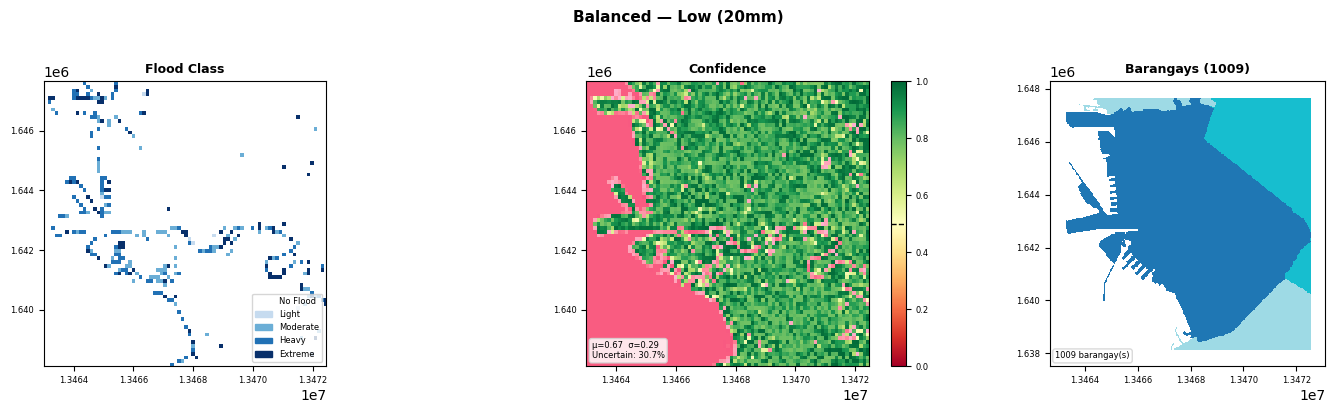

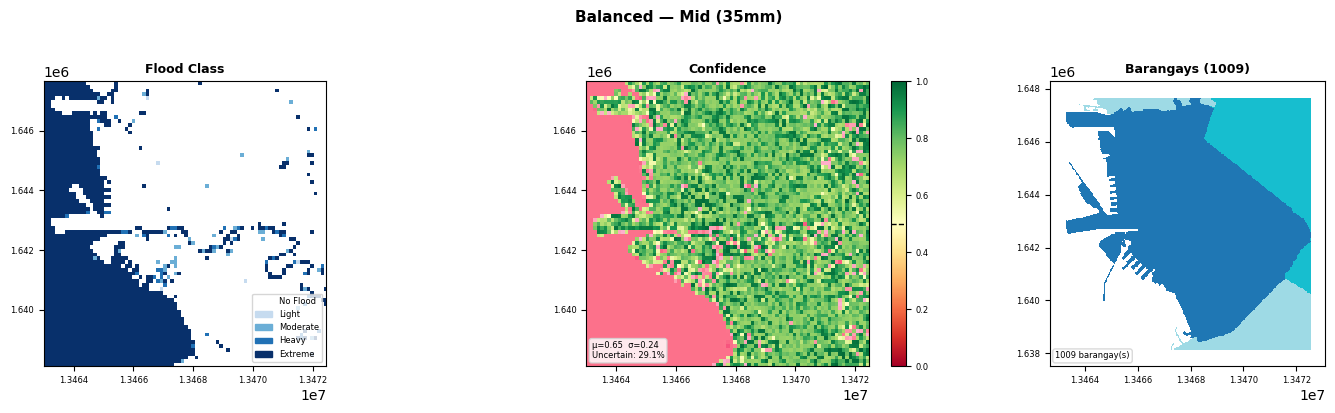

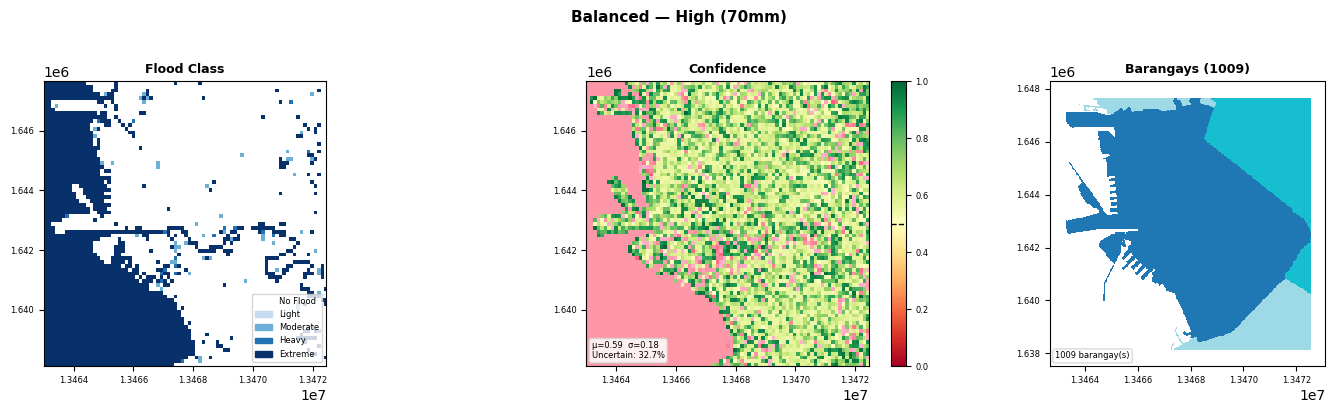

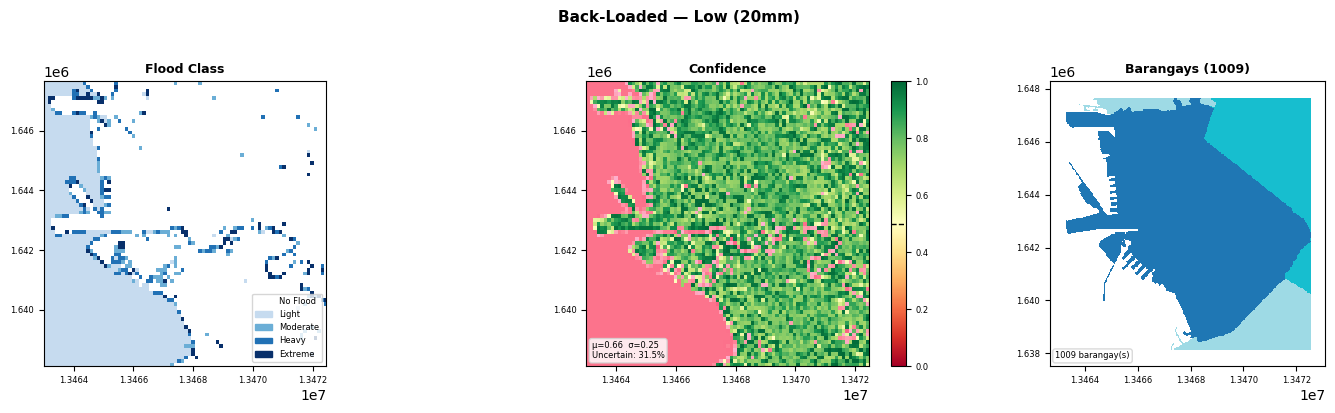

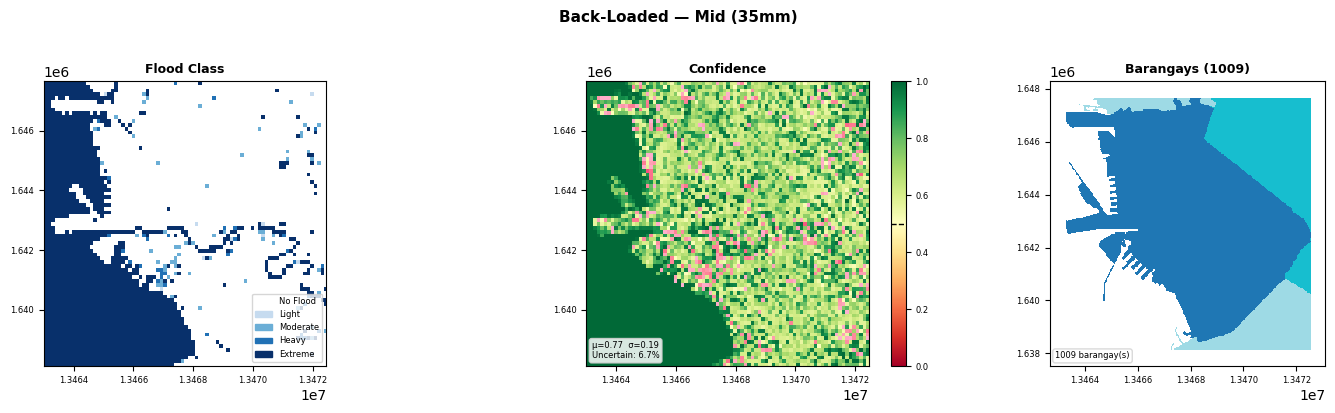

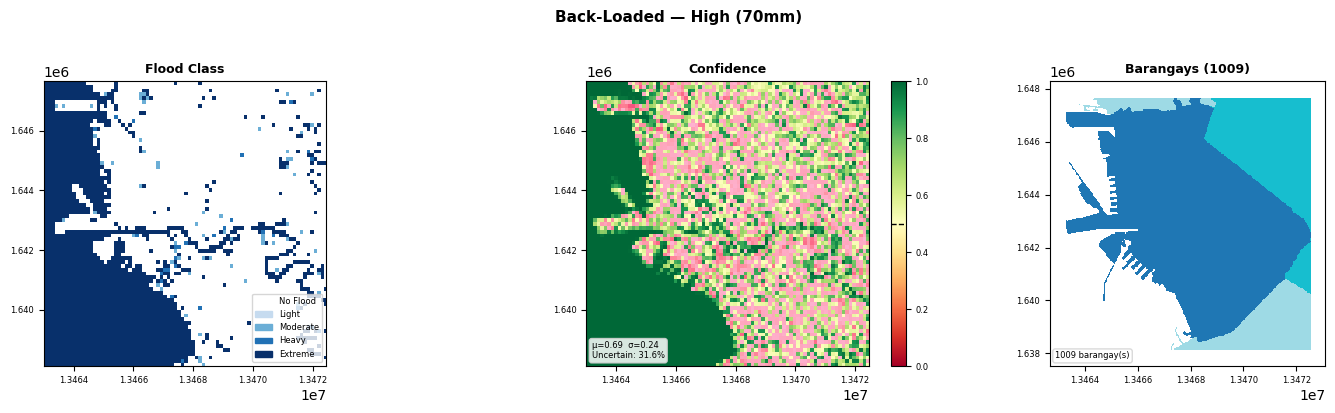

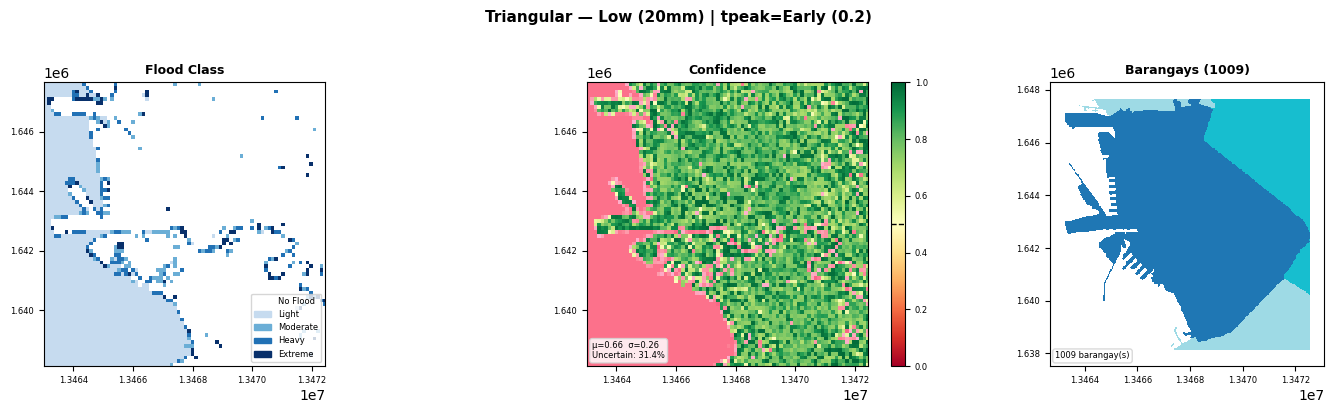

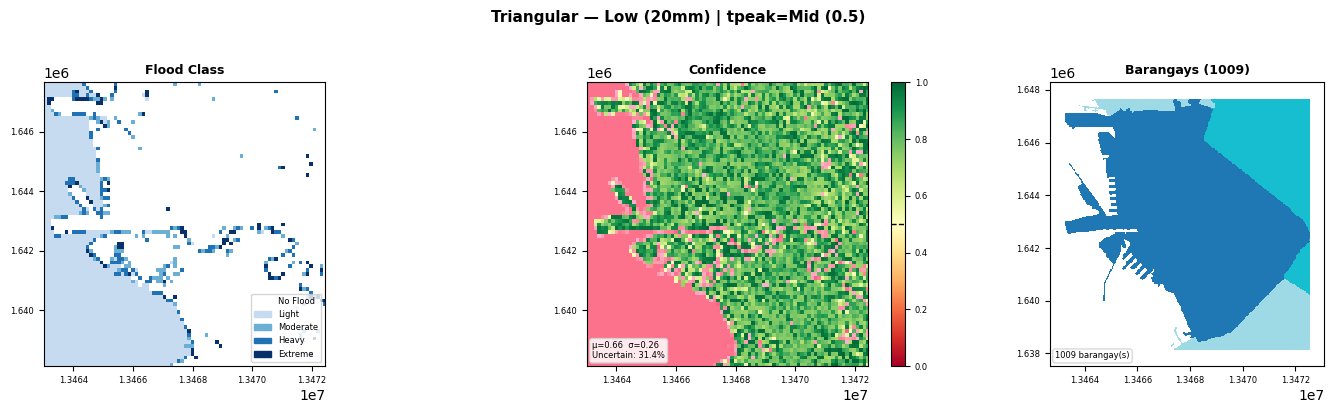

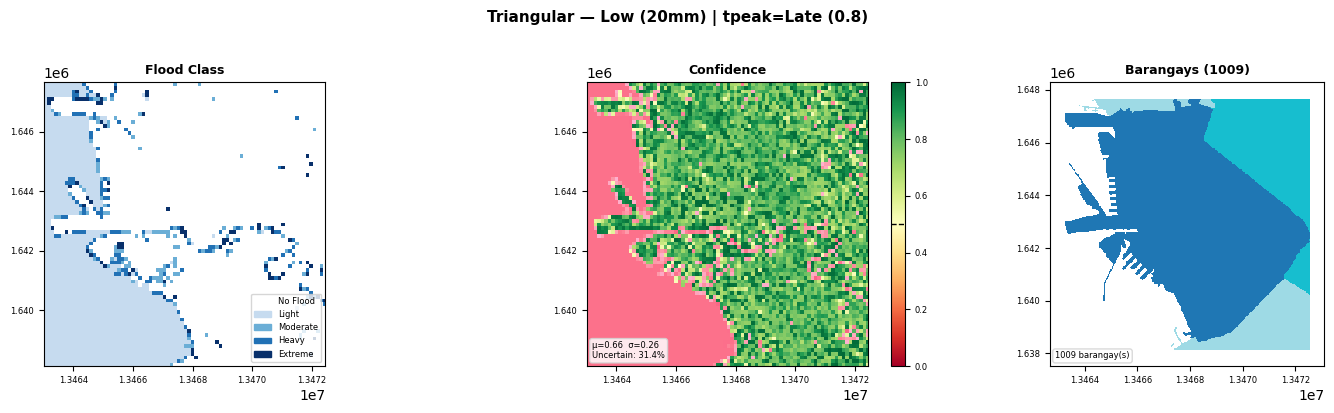

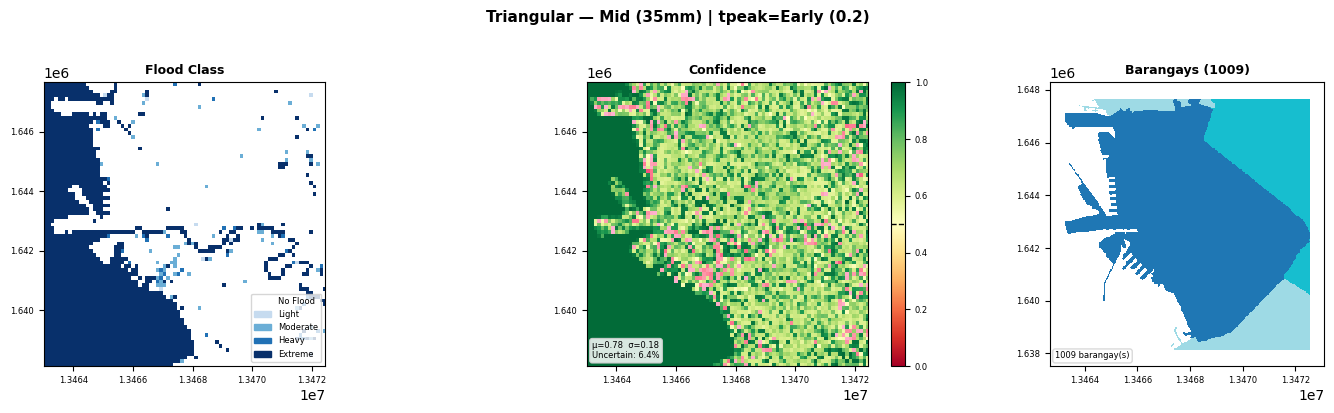

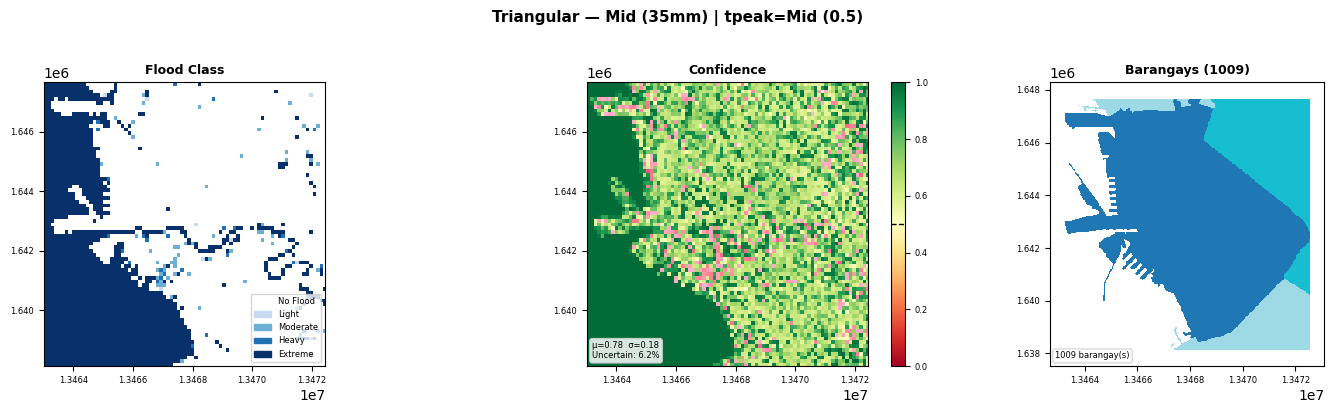

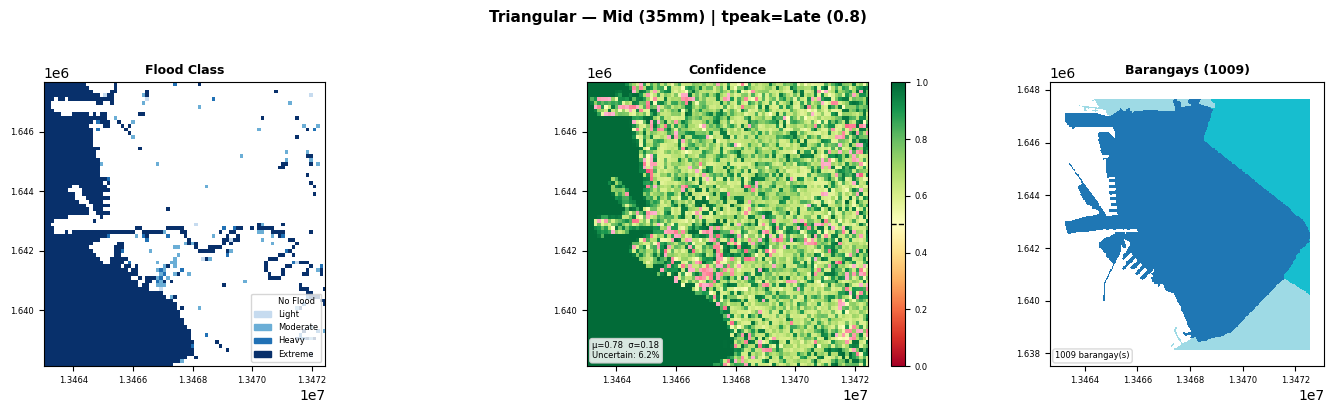

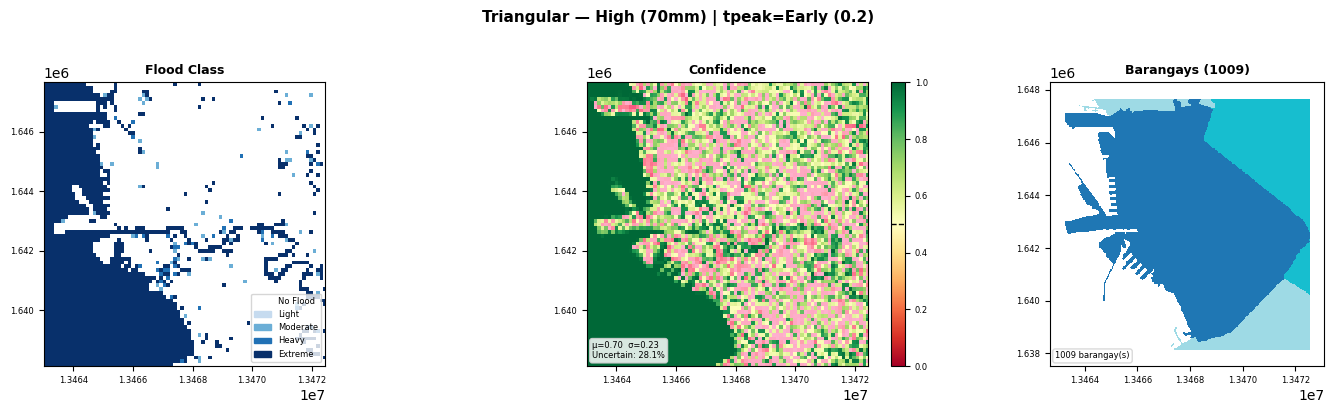

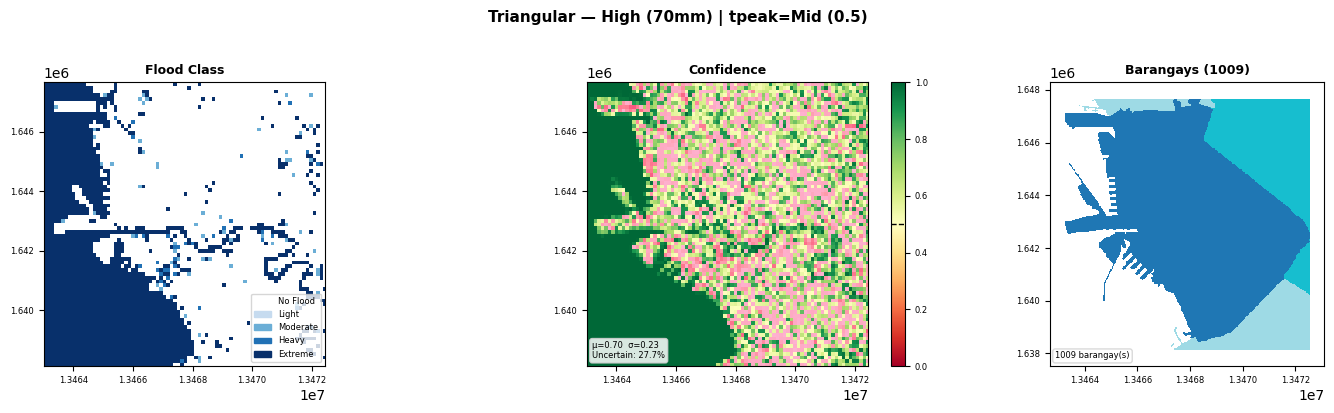

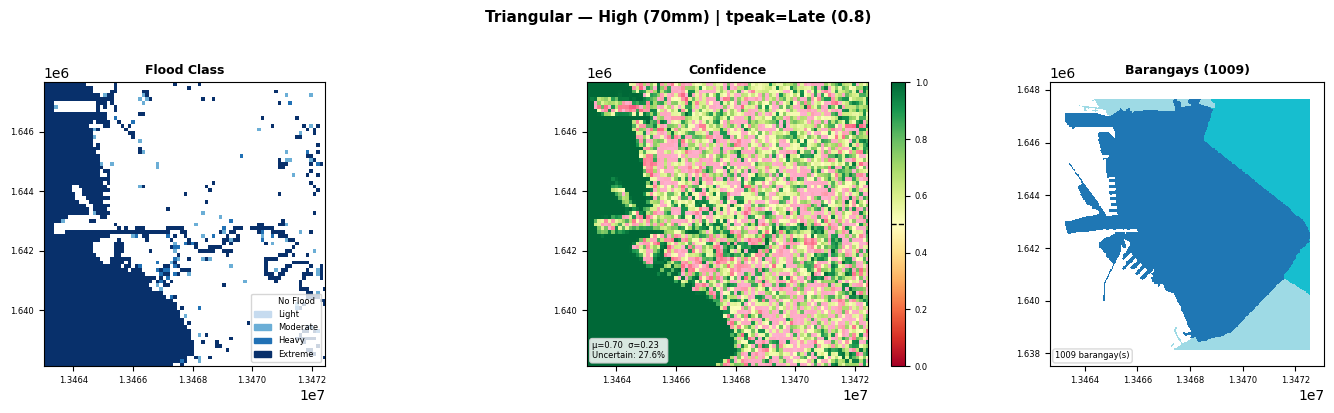

In [3]:
# ── Visualize first ablation TIFFs ───────────────────────────────────────
for storm_type in ['front-loaded', 'balanced', 'back-loaded']:
    for depth in DEPTHS:
        slug  = f"{storm_type.replace('-','_')}_{depth}mm"
        tif   = str(output_dir / f'{slug}.tif')
        title = f"{storm_type.title()} — {DEPTH_LABELS[depth]}"
        visualize_prediction_tiff(tif, title=title)
        plt.show()

for depth in DEPTHS:
    for tpeak in TPEAKS:
        slug  = f"triangular_{depth}mm_tpeak{str(tpeak).replace('.','')}"
        tif   = str(output_dir / f'{slug}.tif')
        title = f"Triangular — {DEPTH_LABELS[depth]} | tpeak={TPEAK_LABELS[tpeak]}"
        visualize_prediction_tiff(tif, title=title)
        plt.show()
